# Paso 1: Preparar el entorno

En esta primera parte cargamos las librerías, definimos las rutas de trabajo y preparamos las funciones básicas para inspeccionar los datos de referencia.

El objetivo es tener una base reproducible antes de avanzar al preprocesado y a la comparación entre sistemas intensivos y extensivos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

BASE_DIR = Path.cwd()
REFERENCE_FILES = {
    "celso_diario": BASE_DIR / "Procesados" / "Celso novo" / "05_original_variables.csv",
    "celso_horario": BASE_DIR / "Procesados" / "Celso novo" / "04_Vacas_etiquetadas_horario.xlsx",
    "ruibal_horario": BASE_DIR / "Procesados" / "Ruibal Riomayor" / "05_Datos_horarios_etiquetados_celo.csv",
}


def load_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    else:
        raise ValueError(f"Formato no soportado: {path.suffix}")

    df.columns = [column.strip() for column in df.columns]
    return df


def get_time_column(df: pd.DataFrame) -> str | None:
    if "Date" in df.columns:
        return "Date"
    if "Time" in df.columns:
        return "Time"
    return None


def summarize_dataset(df: pd.DataFrame) -> pd.Series:
    time_column = get_time_column(df)
    summary = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "cow_count": df["Cow_id"].nunique() if "Cow_id" in df.columns else pd.NA,
        "missing_values": int(df.isna().sum().sum()),
    }

    if time_column is not None:
        time_values = pd.to_datetime(df[time_column], errors="coerce")
        summary["start"] = time_values.min()
        summary["end"] = time_values.max()

    if "Anomaly_Label" in df.columns:
        labels = df["Anomaly_Label"].dropna().astype(str).value_counts()
        summary["top_label"] = labels.index[0] if not labels.empty else pd.NA
        summary["top_label_count"] = int(labels.iloc[0]) if not labels.empty else pd.NA

    return pd.Series(summary)


def plot_numeric_distribution(df: pd.DataFrame, title: str) -> None:
    numeric_cols = [col for col in ["Ruminate", "Eat", "Graze", "Rest", "Walk", "Steps"] if col in df.columns]
    if not numeric_cols:
        return

    ax = df[numeric_cols].hist(figsize=(12, 8), bins=30)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_label_counts(df: pd.DataFrame, title: str) -> None:
    if "Anomaly_Label" not in df.columns:
        return

    counts = df["Anomaly_Label"].fillna("Sin etiqueta").astype(str).value_counts()
    counts.plot(kind="bar", figsize=(8, 4), title=title)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


reference_data = {name: load_dataset(path) for name, path in REFERENCE_FILES.items() if path.exists()}

for name, df in reference_data.items():
    print(f"\n=== {name} ===")
    display(df.head())
    display(summarize_dataset(df).to_frame(name="valor"))

Matplotlib is building the font cache; this may take a moment.



=== celso_diario ===


,Cow_id,Date,Ruminate,Eat,Graze,Rest,Walk,Steps,Anomaly_Label,Description
0,92,2024-04-11,380.367516,485.958045,150.775814,399.898625,0.000000,1115,No anomaly,[])
1,92,2024-04-12,471.729806,285.808873,97.559807,574.901514,1.000000,591,No anomaly,[])
2,92,2024-04-13,458.334484,370.750664,118.510922,452.403930,0.000000,900,No anomaly,[])
3,92,2024-04-14,620.257717,289.810886,151.558599,371.388923,0.983875,1050,No anomaly,[])
4,92,2024-04-15,452.695166,306.173355,182.976630,470.154849,0.000000,1635,No anomaly,[])


,valor
rows,3755
columns,10
cow_count,16
missing_values,0
start,2023-07-09 00:00:00
end,2025-08-03 00:00:00
top_label,No anomaly
top_label_count,3643



=== celso_horario ===


,Cow_id,Date,Ruminate,Eat,Graze,Rest,Walk,Steps,Anomaly_Label
0,90,2025-09-02 00:00:00,0.000000,12.631579,42.631579,4.736842,0.0,221,NaN
1,90,2025-09-02 01:00:00,25.574745,12.789339,9.000000,7.635916,0.0,99,NaN
2,90,2025-09-02 02:00:00,17.242338,23.680184,0.000000,19.077478,0.0,75,NaN
3,90,2025-09-02 03:00:00,38.803171,3.897565,0.000000,17.299264,0.0,0,NaN
4,90,2025-09-02 04:00:00,30.379747,10.632911,0.000000,18.987342,0.0,116,NaN


,valor
rows,720131
columns,9
cow_count,108
missing_values,718750
start,2023-07-09 00:00:00
end,2025-09-15 23:00:00
top_label,Heat
top_label_count,1381



=== ruibal_horario ===


,Cow_id,Time,Rest,Graze,Walk,Ruminate,Eat,Steps,Anomaly_Label,Description,Anomaly_quality,Anomaly_hour,Anomaly_duration
0,ES000000001058,2025-02-27 00:00:00,11.000000,0.000000,0.0,45.000000,3.000000,0.0,NaN,NaN,NaN,NaN,NaN
1,ES000000001058,2025-02-27 01:00:00,23.000000,0.000000,0.0,20.000000,15.000000,11.0,NaN,NaN,NaN,NaN,NaN
2,ES000000001058,2025-02-27 02:00:00,20.391548,0.000000,0.0,35.040251,4.568200,0.0,NaN,NaN,NaN,NaN,NaN
3,ES000000001058,2025-02-27 03:00:00,20.320432,0.000009,0.0,32.434169,7.245391,30.0,NaN,NaN,NaN,NaN,NaN
4,ES000000001058,2025-02-27 04:00:00,11.169271,0.000529,0.0,40.660669,8.169531,120.0,NaN,NaN,NaN,NaN,NaN


,valor
rows,454296
columns,13
cow_count,93
missing_values,2229260
start,2024-03-08 00:00:00
end,2025-08-08 23:00:00
top_label,Heat/Estrus
top_label_count,10716


# Paso 2: Ejecutar el primer paso

Cargamos los datasets de referencia y comprobamos su estructura básica. Esto nos sirve para comparar el formato diario y horario antes de preparar el preprocesado para nuevas granjas.

In [2]:
for name, df in reference_data.items():
    print(f"\nResumen de {name}")
    summary = summarize_dataset(df)
    display(summary.to_frame(name="valor"))
    print("Columnas:", list(df.columns))
    if "Anomaly_Label" in df.columns:
        print("Etiquetas:")
        print(df["Anomaly_Label"].fillna("Sin etiqueta").astype(str).value_counts().head(10))


Resumen de celso_diario


,valor
rows,3755
columns,10
cow_count,16
missing_values,0
start,2023-07-09 00:00:00
end,2025-08-03 00:00:00
top_label,No anomaly
top_label_count,3643


Columnas: ['Cow_id', 'Date', 'Ruminate', 'Eat', 'Graze', 'Rest', 'Walk', 'Steps', 'Anomaly_Label', 'Description']
Etiquetas:
Anomaly_Label
No anomaly    3643
Heat           112
Name: count, dtype: int64

Resumen de celso_horario


,valor
rows,720131
columns,9
cow_count,108
missing_values,718750
start,2023-07-09 00:00:00
end,2025-09-15 23:00:00
top_label,Heat
top_label_count,1381


Columnas: ['Cow_id', 'Date', 'Ruminate', 'Eat', 'Graze', 'Rest', 'Walk', 'Steps', 'Anomaly_Label']
Etiquetas:
Anomaly_Label
Sin etiqueta    718750
Heat              1381
Name: count, dtype: int64

Resumen de ruibal_horario


,valor
rows,454296
columns,13
cow_count,93
missing_values,2229260
start,2024-03-08 00:00:00
end,2025-08-08 23:00:00
top_label,Heat/Estrus
top_label_count,10716


Columnas: ['Cow_id', 'Time', 'Rest', 'Graze', 'Walk', 'Ruminate', 'Eat', 'Steps', 'Anomaly_Label', 'Description', 'Anomaly_quality', 'Anomaly_hour', 'Anomaly_duration']
Etiquetas:
Anomaly_Label
Sin etiqueta    442563
Heat/Estrus      10716
Other             1017
Name: count, dtype: int64


# Paso 3: Ejecutar el segundo paso

Generamos primeras gráficas para revisar la distribución de las variables de actividad y de las etiquetas de anomalía. Esto nos ayudará a detectar diferencias básicas entre ficheros antes del preprocesado formal.


Graficas de celso_diario


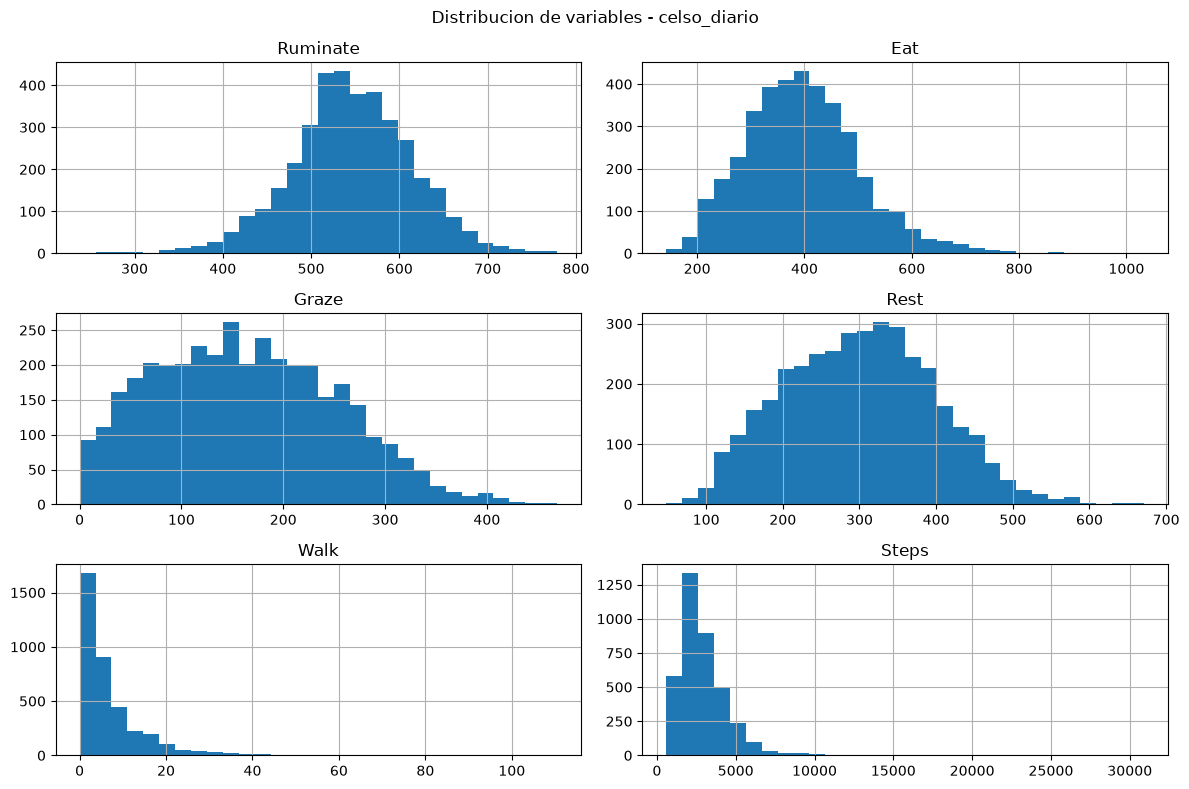

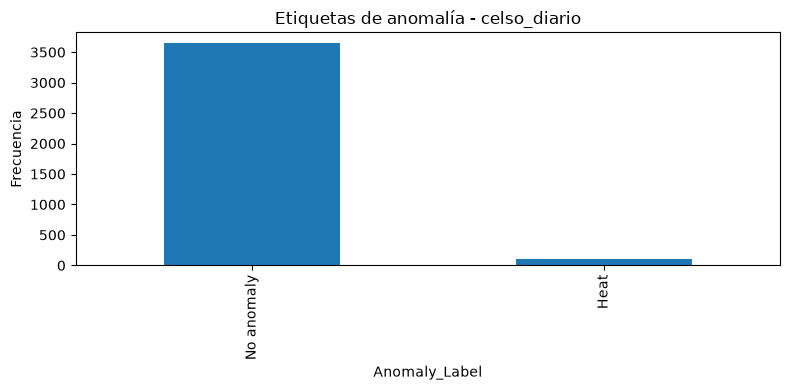


Graficas de celso_horario


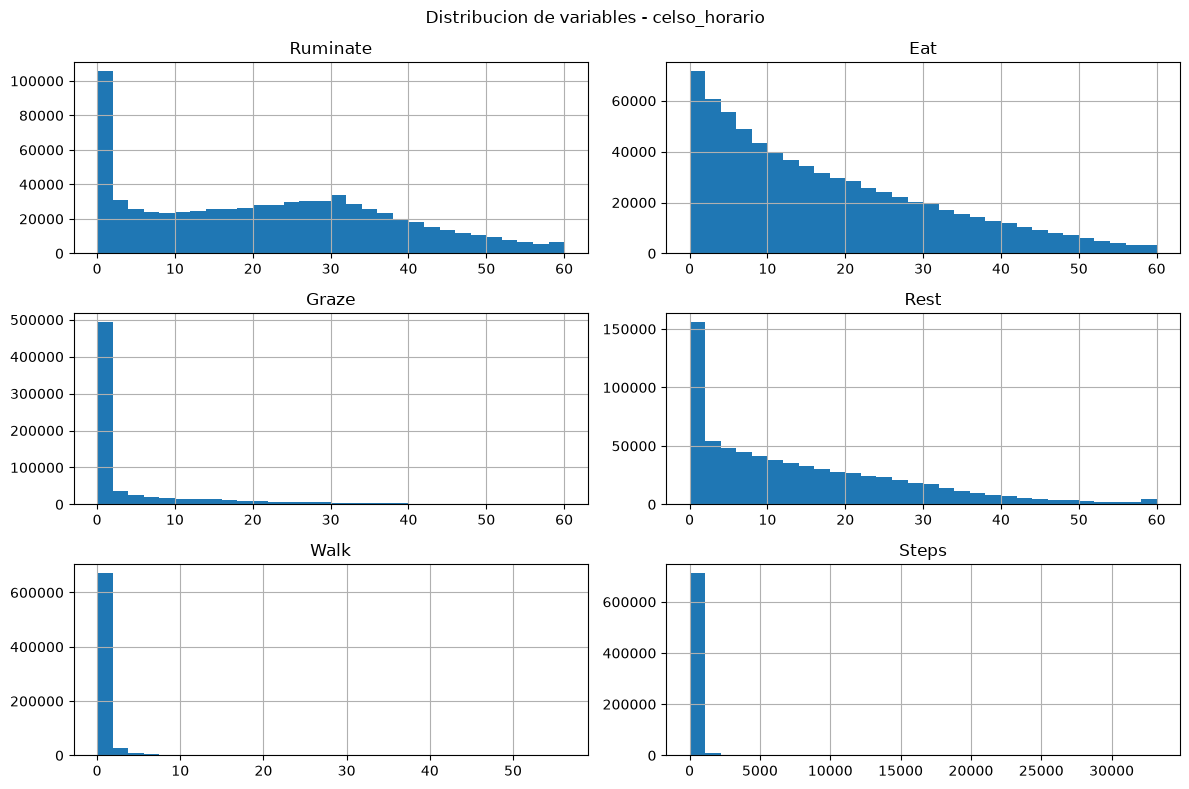

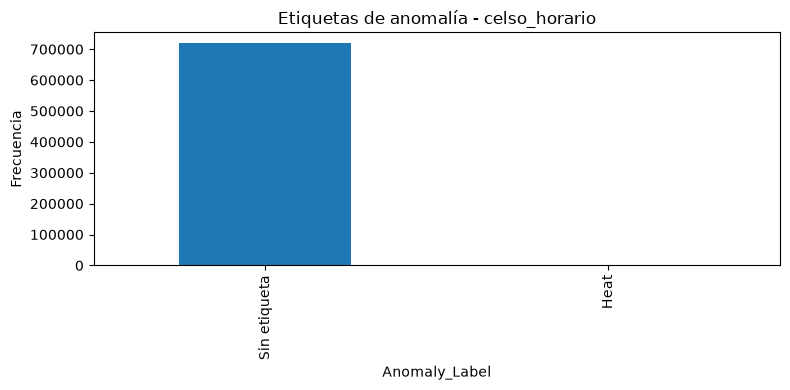


Graficas de ruibal_horario


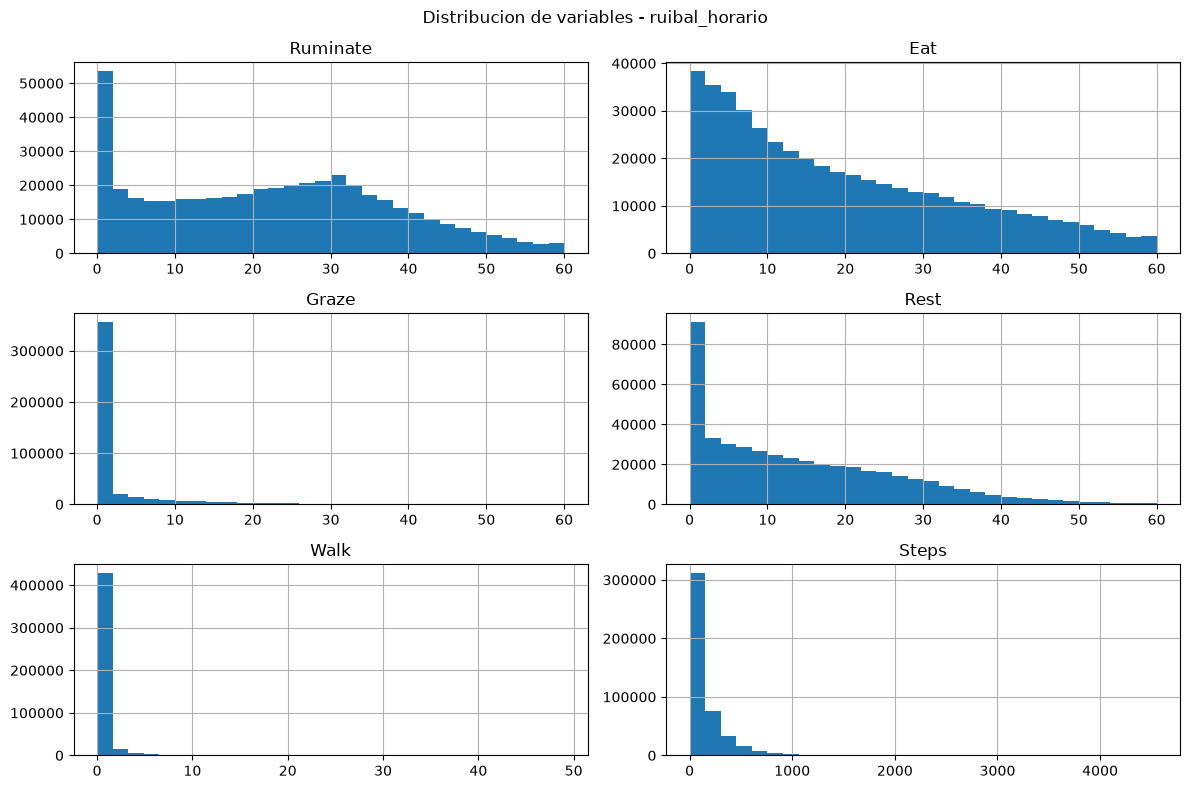

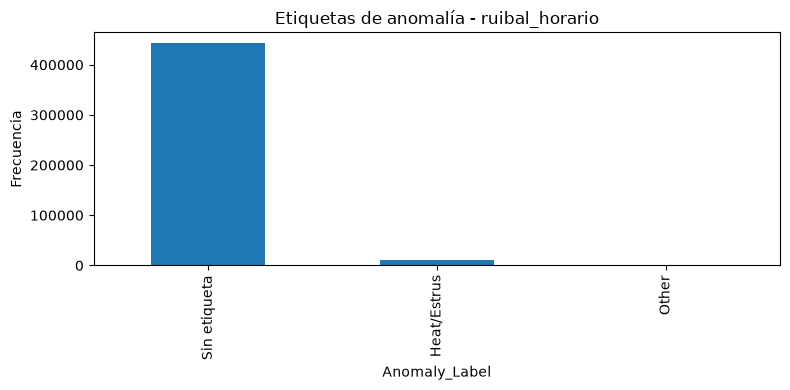

In [3]:
for name, df in reference_data.items():
    print(f"\nGraficas de {name}")
    plot_numeric_distribution(df, f"Distribucion de variables - {name}")
    plot_label_counts(df, f"Etiquetas de anomalía - {name}")